In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/ASSIGNMENTS/ML/A2/Dry_Bean_Dataset.xlsx")

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

In [ ]:
df.shape

(13611, 17)

In [ ]:
df.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [ ]:
df["Class"].value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


In [ ]:
y = df["Class"]

In [ ]:
X = df.drop("Class", axis=1)

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13611, 16)
y shape: (13611,)


In [ ]:
X.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [ ]:
y.head()

,Class
0,SEKER
1,SEKER
2,SEKER
3,SEKER
4,SEKER


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [ ]:
print(label_encoder.classes_)

['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [ ]:
print(y_encoded[:10])

[5 5 5 5 5 5 5 5 5 5]


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (10888, 16)
X_test : (2723, 16)
y_train: (10888,)
y_test : (2723,)


In [ ]:
print("Training classes:")
print(pd.Series(y_train).value_counts())

Training classes:
3    2837
6    2109
5    1621
4    1542
2    1304
0    1057
1     418
Name: count, dtype: int64


In [ ]:
print("\nTesting classes:")
print(pd.Series(y_test).value_counts())


Testing classes:
3    709
6    527
5    406
4    386
2    326
0    265
1    104
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Before scaling:")
print(X_train.iloc[:5, :3])

print("\nAfter scaling:")
print(X_train_scaled[:5, :3])

Before scaling:
       Area  Perimeter  MajorAxisLength
1453  42142    741.324       260.523582
6470  53866    961.806       387.117925
4639  74312   1025.211       390.615917
4655  74460   1044.175       407.437813
1936  49108    799.901       278.853164

After scaling:
[[-0.3713618  -0.53113068 -0.69536968]
 [ 0.02895235  0.49881788  0.78351767]
 [ 0.72707783  0.79500482  0.82438155]
 [ 0.73213127  0.8835923   1.02089657]
 [-0.13350882 -0.25749702 -0.48124173]]


In [ ]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (10888, 16)
X_test_scaled shape : (2723, 16)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = logistic_model.predict(X_test_scaled)

In [ ]:
print(y_pred_lr[:20])

[3 1 6 5 0 5 3 6 2 4 3 3 3 4 2 3 5 3 1 1]


In [ ]:
print(label_encoder.inverse_transform(y_pred_lr[:20]))

['DERMASON' 'BOMBAY' 'SIRA' 'SEKER' 'BARBUNYA' 'SEKER' 'DERMASON' 'SIRA'
 'CALI' 'HOROZ' 'DERMASON' 'DERMASON' 'DERMASON' 'HOROZ' 'CALI' 'DERMASON'
 'SEKER' 'DERMASON' 'BOMBAY' 'BOMBAY']


In [ ]:
print("Actual:")
print(label_encoder.inverse_transform(y_test[:10]))

print("\nPredicted:")
print(label_encoder.inverse_transform(y_pred_lr[:10]))

Actual:
['DERMASON' 'BOMBAY' 'SIRA' 'SEKER' 'BARBUNYA' 'SEKER' 'DERMASON' 'SIRA'
 'BARBUNYA' 'HOROZ']

Predicted:
['DERMASON' 'BOMBAY' 'SIRA' 'SEKER' 'BARBUNYA' 'SEKER' 'DERMASON' 'SIRA'
 'CALI' 'HOROZ']


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9214102093279471


Probability **prediction**

In [ ]:
y_prob_lr = logistic_model.predict_proba(X_test_scaled)

In [ ]:
print(y_prob_lr.shape)

(2723, 7)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)
print("Probability shape:", y_prob_lr.shape)

Accuracy: 0.9214102093279471
Probability shape: (2723, 7)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

In [ ]:
auc_lr = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class="ovr",
    average="weighted"
)

In [ ]:
precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

In [ ]:
recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

In [ ]:
f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

In [ ]:
mcc_lr = matthews_corrcoef(
    y_test,
    y_pred_lr
)

In [ ]:
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("AUC      :", auc_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)
print("MCC      :", mcc_lr)

Logistic Regression Results
---------------------------
Accuracy : 0.9214102093279471
AUC      : 0.993407534398682
Precision: 0.9221784239573475
Recall   : 0.9214102093279471
F1 Score : 0.9215897790418328
MCC      : 0.9050454594545089


##Classification Report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

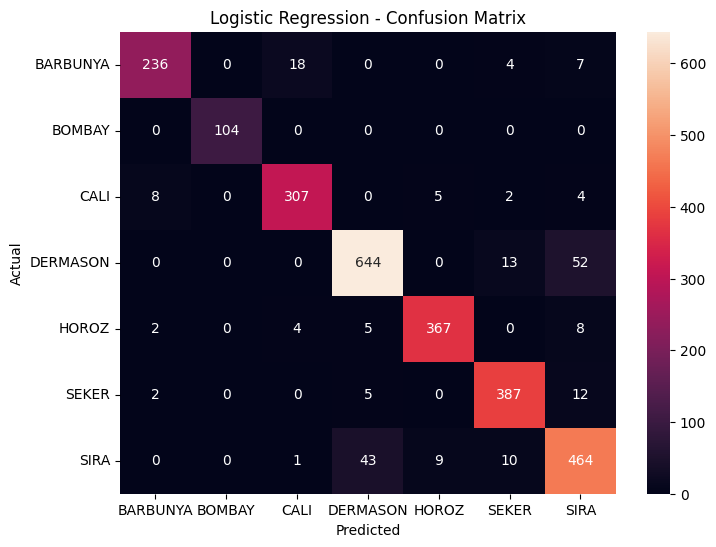

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(y_test, y_pred)

    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    }

In [ ]:
lr_results = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test
)

In [ ]:
print(lr_results)

{'Accuracy': 0.9214102093279471, 'AUC': np.float64(0.993407534398682), 'Precision': 0.9221784239573475, 'Recall': 0.9214102093279471, 'F1': 0.9215897790418328, 'MCC': np.float64(0.9050454594545089)}


In [ ]:
results = []

results.append({
    "Model": "Logistic Regression",
    **lr_results
})

In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.92141,0.993408,0.922178,0.92141,0.92159,0.905045


##DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_results = evaluate_model(
    decision_tree_model,
    X_test,
    y_test
)

print(dt_results)

{'Accuracy': 0.8920308483290489, 'AUC': np.float64(0.9333762814552742), 'Precision': 0.8916927238123676, 'Recall': 0.8920308483290489, 'F1': 0.891630337288096, 'MCC': np.float64(0.8695693170006366)}


In [ ]:
y_pred = decision_tree_model.predict(X_test)

print(y_pred[:10])

[3 1 6 5 0 5 3 6 2 4]


In [ ]:
print(label_encoder.inverse_transform(y_pred[:10]))

['DERMASON' 'BOMBAY' 'SIRA' 'SEKER' 'BARBUNYA' 'SEKER' 'DERMASON' 'SIRA'
 'CALI' 'HOROZ']


In [ ]:
results.append({
    "Model": "Decision Tree",
    **dt_results
})

In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.921410,0.993408,0.922178,0.921410,0.92159,0.905045
1,Decision Tree,0.892031,0.933376,0.891693,0.892031,0.89163,0.869569


##k-Nearest Neighbors (kNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_scaled
)

knn_results = evaluate_model(
    knn_model,
    X_test_scaled,
    y_test
)

print("kNN Results:")
print(knn_results)

kNN Results:
{'Accuracy': 0.9166360631656262, 'AUC': np.float64(0.9812466098253438), 'Precision': 0.9174092603022151, 'Recall': 0.9166360631656262, 'F1': 0.9168048079580466, 'MCC': np.float64(0.8992035213926259)}


In [ ]:
results.append({
    "Model": "kNN",
    **knn_results
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.921410,0.993408,0.922178,0.921410,0.921590,0.905045
1,Decision Tree,0.892031,0.933376,0.891693,0.892031,0.891630,0.869569
2,kNN,0.916636,0.981247,0.917409,0.916636,0.916805,0.899204


##Naive Bayes Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(
    X_train,
    y_train
)

y_pred_nb = nb_model.predict(
    X_test
)

nb_results = evaluate_model(
    nb_model,
    X_test,
    y_test
)

print("Naive Bayes Results:")
print(nb_results)

Naive Bayes Results:
{'Accuracy': 0.7638633859713552, 'AUC': np.float64(0.9644421096213359), 'Precision': 0.7653708847319572, 'Recall': 0.7638633859713552, 'F1': 0.7614742997970327, 'MCC': np.float64(0.7154063217966201)}


In [ ]:
results.append({
    "Model": "Naive Bayes",
    **nb_results
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.921410,0.993408,0.922178,0.921410,0.921590,0.905045
1,Decision Tree,0.892031,0.933376,0.891693,0.892031,0.891630,0.869569
2,kNN,0.916636,0.981247,0.917409,0.916636,0.916805,0.899204
3,Naive Bayes,0.763863,0.964442,0.765371,0.763863,0.761474,0.715406


##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
random_forest_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = random_forest_model.predict(
    X_test
)

In [ ]:
print(y_pred_rf[:10])

[3 1 6 5 0 5 3 6 2 4]


In [ ]:
rf_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

In [ ]:
print("Random Forest Results:")
print(rf_results)

Random Forest Results:
{'Accuracy': 0.9203084832904884, 'AUC': np.float64(0.9914565371175954), 'Precision': 0.9204695570622978, 'Recall': 0.9203084832904884, 'F1': 0.9202830013062294, 'MCC': np.float64(0.9036061590184772)}


In [ ]:
results.append({
    "Model": "Random Forest (Ensemble)",
    **rf_results
})

In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.921410,0.993408,0.922178,0.921410,0.921590,0.905045
1,Decision Tree,0.892031,0.933376,0.891693,0.892031,0.891630,0.869569
2,kNN,0.916636,0.981247,0.917409,0.916636,0.916805,0.899204
3,Naive Bayes,0.763863,0.964442,0.765371,0.763863,0.761474,0.715406
4,Random Forest (Ensemble),0.920308,0.991457,0.920470,0.920308,0.920283,0.903606


In [ ]:
results_df.round(4)

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9214,0.9934,0.9222,0.9214,0.9216,0.9050
1,Decision Tree,0.8920,0.9334,0.8917,0.8920,0.8916,0.8696
2,kNN,0.9166,0.9812,0.9174,0.9166,0.9168,0.8992
3,Naive Bayes,0.7639,0.9644,0.7654,0.7639,0.7615,0.7154
4,Random Forest (Ensemble),0.9203,0.9915,0.9205,0.9203,0.9203,0.9036


In [ ]:
results_df.loc[
    results_df["Accuracy"].idxmax()
]

,0
Model,Logistic Regression
Accuracy,0.92141
AUC,0.993408
Precision,0.922178
Recall,0.92141
F1,0.92159
MCC,0.905045


In [ ]:
results_df.loc[
    results_df["F1"].idxmax()
]

,0
Model,Logistic Regression
Accuracy,0.92141
AUC,0.993408
Precision,0.922178
Recall,0.92141
F1,0.92159
MCC,0.905045


In [ ]:
results_df.loc[
    results_df["MCC"].idxmax()
]

,0
Model,Logistic Regression
Accuracy,0.92141
AUC,0.993408
Precision,0.922178
Recall,0.92141
F1,0.92159
MCC,0.905045


##comparison table

In [ ]:
results_df = results_df.round(4)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9214,0.9934,0.9222,0.9214,0.9216,0.9050
1,Decision Tree,0.8920,0.9334,0.8917,0.8920,0.8916,0.8696
2,kNN,0.9166,0.9812,0.9174,0.9166,0.9168,0.8992
3,Naive Bayes,0.7639,0.9644,0.7654,0.7639,0.7615,0.7154
4,Random Forest (Ensemble),0.9203,0.9915,0.9205,0.9203,0.9203,0.9036


In [ ]:
results_df.to_csv(
    "/content/drive/MyDrive/ASSIGNMENTS/ML/A2/metrics.csv",
    index=False
)

In [ ]:
for metric in ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]:
    best_model = results_df.loc[
        results_df[metric].idxmax(), "Model"
    ]

    print(f"Best {metric}: {best_model}")

Best Accuracy: Logistic Regression
Best AUC: Logistic Regression
Best Precision: Logistic Regression
Best Recall: Logistic Regression
Best F1: Logistic Regression
Best MCC: Logistic Regression


#Classification Report for ALL models

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
classification_reports = {}

In [ ]:
classification_reports["Logistic Regression"] = classification_report(
    y_test,
    logistic_model.predict(X_test_scaled),
    target_names=label_encoder.classes_
)

classification_reports["Decision Tree"] = classification_report(
    y_test,
    decision_tree_model.predict(X_test),
    target_names=label_encoder.classes_
)

classification_reports["kNN"] = classification_report(
    y_test,
    knn_model.predict(X_test_scaled),
    target_names=label_encoder.classes_
)

classification_reports["Naive Bayes"] = classification_report(
    y_test,
    nb_model.predict(X_test),
    target_names=label_encoder.classes_
)

classification_reports["Random Forest (Ensemble)"] = classification_report(
    y_test,
    random_forest_model.predict(X_test),
    target_names=label_encoder.classes_
)

In [ ]:
print(classification_reports["Logistic Regression"])

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



##Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

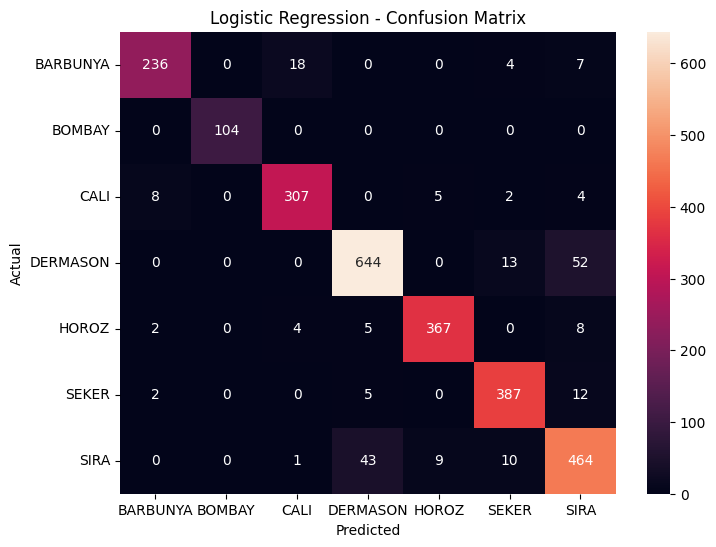

In [ ]:
y_pred_lr = logistic_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

##Trained Models Save

In [ ]:
import joblib
import os

In [ ]:
model_path = "/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model"

In [ ]:
os.makedirs(model_path, exist_ok=True)

In [ ]:
joblib.dump(
    logistic_model,
    f"{model_path}/logistic_regression.joblib"
)

['/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/logistic_regression.joblib']

In [ ]:
joblib.dump(
    decision_tree_model,
    f"{model_path}/decision_tree.joblib"
)

['/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/decision_tree.joblib']

In [ ]:
joblib.dump(
    knn_model,
    f"{model_path}/knn.joblib"
)

['/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/knn.joblib']

In [ ]:
joblib.dump(
    nb_model,
    f"{model_path}/naive_bayes.joblib"
)

['/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/naive_bayes.joblib']

In [ ]:
joblib.dump(
    random_forest_model,
    f"{model_path}/random_forest.joblib"
)

['/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/random_forest.joblib']

In [ ]:
joblib.dump(
    scaler,
    f"{model_path}/scaler.joblib"
)

['/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/scaler.joblib']

In [ ]:
joblib.dump(
    label_encoder,
    f"{model_path}/label_encoder.joblib"
)

['/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/label_encoder.joblib']

In [ ]:
print(os.listdir(model_path))

['logistic_regression.joblib', 'decision_tree.joblib', 'knn.joblib', 'naive_bayes.joblib', 'random_forest.joblib', 'scaler.joblib', 'label_encoder.joblib']


In [ ]:
test_data = X_test.copy()

In [ ]:
test_data.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
12803,36002,700.889,257.888986,178.268649,1.446631,0.722605,36368,214.100841,0.797386,0.989936,0.920954,0.830205,0.007163,0.002099,0.689241,0.997078
3713,183825,1594.423,582.225240,402.762055,1.445581,0.722124,185116,483.790512,0.797852,0.993026,0.908672,0.830934,0.003167,0.000931,0.690451,0.998102
8974,45595,801.717,301.092828,193.505323,1.555992,0.766138,46054,240.942643,0.769926,0.990033,0.891425,0.800227,0.006604,0.001670,0.640363,0.996401
1743,45084,763.811,261.138204,219.977872,1.187111,0.538882,45425,239.588672,0.773098,0.992493,0.971092,0.917478,0.005792,0.002532,0.841767,0.999271
2303,61645,952.199,335.139136,235.843970,1.421021,0.710478,62499,280.158619,0.795522,0.986336,0.854382,0.835947,0.005437,0.001638,0.698808,0.993020


In [ ]:
test_data_path = "/content/drive/MyDrive/ASSIGNMENTS/ML/A2/test_data.csv"

test_data.to_csv(
    test_data_path,
    index=False
)

In [ ]:
print(test_data_path)

/content/drive/MyDrive/ASSIGNMENTS/ML/A2/test_data.csv


In [ ]:
print(test_data.shape)

(2723, 16)


In [ ]:
test_data.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
12803,36002,700.889,257.888986,178.268649,1.446631,0.722605,36368,214.100841,0.797386,0.989936,0.920954,0.830205,0.007163,0.002099,0.689241,0.997078
3713,183825,1594.423,582.225240,402.762055,1.445581,0.722124,185116,483.790512,0.797852,0.993026,0.908672,0.830934,0.003167,0.000931,0.690451,0.998102
8974,45595,801.717,301.092828,193.505323,1.555992,0.766138,46054,240.942643,0.769926,0.990033,0.891425,0.800227,0.006604,0.001670,0.640363,0.996401
1743,45084,763.811,261.138204,219.977872,1.187111,0.538882,45425,239.588672,0.773098,0.992493,0.971092,0.917478,0.005792,0.002532,0.841767,0.999271
2303,61645,952.199,335.139136,235.843970,1.421021,0.710478,62499,280.158619,0.795522,0.986336,0.854382,0.835947,0.005437,0.001638,0.698808,0.993020


In [ ]:
test_check = pd.read_csv(test_data_path)

print(test_check.shape)
print(test_check.head())

(2723, 16)
     Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0   36002    700.889       257.888986       178.268649      1.446631   
1  183825   1594.423       582.225240       402.762055      1.445581   
2   45595    801.717       301.092828       193.505323      1.555992   
3   45084    763.811       261.138204       219.977872      1.187111   
4   61645    952.199       335.139136       235.843970      1.421021   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.722605       36368     214.100841  0.797386  0.989936   0.920954   
1      0.722124      185116     483.790512  0.797852  0.993026   0.908672   
2      0.766138       46054     240.942643  0.769926  0.990033   0.891425   
3      0.538882       45425     239.588672  0.773098  0.992493   0.971092   
4      0.710478       62499     280.158619  0.795522  0.986336   0.854382   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  
0     0.830205      

In [ ]:
print(test_check.shape)

(2723, 16)


In [ ]:
uploaded_test = pd.read_csv(test_data_path)

In [ ]:
loaded_scaler = joblib.load(
    "/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/scaler.joblib"
)

In [ ]:
loaded_lr = joblib.load(
    "/content/drive/MyDrive/ASSIGNMENTS/ML/A2/model/logistic_regression.joblib"
)

In [ ]:
uploaded_test_scaled = loaded_scaler.transform(
    uploaded_test
)

In [ ]:
predictions = loaded_lr.predict(
    uploaded_test_scaled
)

In [ ]:
predicted_classes = label_encoder.inverse_transform(
    predictions
)

In [ ]:
print(predicted_classes[:20])

['DERMASON' 'BOMBAY' 'SIRA' 'SEKER' 'BARBUNYA' 'SEKER' 'DERMASON' 'SIRA'
 'CALI' 'HOROZ' 'DERMASON' 'DERMASON' 'DERMASON' 'HOROZ' 'CALI' 'DERMASON'
 'SEKER' 'DERMASON' 'BOMBAY' 'BOMBAY']


In [ ]:
test_data = X_test.copy()

test_data["Class"] = label_encoder.inverse_transform(y_test)

test_data_path = "/content/drive/MyDrive/ASSIGNMENTS/ML/A2/test_data.csv"

test_data.to_csv(
    test_data_path,
    index=False
)

print("Test data saved successfully!")
print("Shape:", test_data.shape)

Test data saved successfully!
Shape: (2723, 17)


In [ ]:
test_check = pd.read_csv(test_data_path)

print(test_check.shape)

test_check.head()

(2723, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,36002,700.889,257.888986,178.268649,1.446631,0.722605,36368,214.100841,0.797386,0.989936,0.920954,0.830205,0.007163,0.002099,0.689241,0.997078,DERMASON
1,183825,1594.423,582.225240,402.762055,1.445581,0.722124,185116,483.790512,0.797852,0.993026,0.908672,0.830934,0.003167,0.000931,0.690451,0.998102,BOMBAY
2,45595,801.717,301.092828,193.505323,1.555992,0.766138,46054,240.942643,0.769926,0.990033,0.891425,0.800227,0.006604,0.001670,0.640363,0.996401,SIRA
3,45084,763.811,261.138204,219.977872,1.187111,0.538882,45425,239.588672,0.773098,0.992493,0.971092,0.917478,0.005792,0.002532,0.841767,0.999271,SEKER
4,61645,952.199,335.139136,235.843970,1.421021,0.710478,62499,280.158619,0.795522,0.986336,0.854382,0.835947,0.005437,0.001638,0.698808,0.993020,BARBUNYA
